# Pleasant Weather Outlook (Temperature & Dewpoint plot)
Using Temperature (TMP), Wind Speed (WIND), Dewpoint (DPT) and Total Cloud Cover (TCDC), this is an index for displaying which areas will experience comfortable weather.

In [27]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask

In [38]:
run = pd.Timestamp("2024-10-09-00")

H = FastHerbie([run], model="nam", product="conusnest.hiresf", fxx=np.arange(0,61,3).tolist(), save_dir='./data/', overwrite=True)

ss2 = '((UGRD|VGRD):(10 m ))|(TCDC)|((TMP|DPT):(2 m ))'
ss2 = H.xarray(ss2)

ss2[1]['wsp'] = np.sqrt(ss2[1]['u10']**2+ss2[1]['v10']**2) 
ss2[1]['tcc'] = ss2[0]['tcc']
ss2[1]['t2m'] = ss2[2]['t2m']
ss2[1]['d2m'] = ss2[2]['d2m']
ds = ss2[1]
ds = ds.drop_vars('u10')
ds = ds.drop_vars('v10')

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:1280: UserWarning: Will not remove GRIB file because it previously existed.
  warnings.warn("Will not remove GRIB file because it previously existed.")
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='ov

In [29]:
ds['t2m_F'] = (ds['t2m'] - 273.15) * 9/5 + 32
ds['d2m_F'] = (ds['d2m'] - 273.15) * 9/5 + 32
ds['wsp_mph'] = ds['wsp'] * 2.236936
ds

<xarray.Dataset> Size: 1GB
Dimensions:                (step: 21, y: 1059, x: 1799)
Coordinates:
  * step                   (step) timedelta64[ns] 168B 00:00:00 ... 2 days 12...
    time                   datetime64[ns] 8B 2024-10-09
    heightAboveGround      float64 8B 10.0
    latitude               (y, x) float64 15MB 21.14 21.14 21.15 ... 47.85 47.84
    longitude              (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    valid_time             (step) datetime64[ns] 168B 2024-10-09 ... 2024-10-...
    gribfile_projection    object 8B None
    atmosphereSingleLayer  float64 8B 0.0
Dimensions without coordinates: y, x
Data variables:
    wsp                    (step, y, x) float32 160MB 5.656 5.675 ... 8.018
    tcc                    (step, y, x) float32 160MB 100.0 100.0 ... 73.0 77.0
    t2m                    (step, y, x) float32 160MB 296.5 296.5 ... 283.1
    d2m                    (step, y, x) float32 160MB 294.6 294.6 ... 280.6
    t2m_F                  (step, y, x) float32 160MB 73.94 74.01 ... 49.89
    d2m_F                  (step, y, x) float32 160MB 70.66 70.7 ... 44.69 45.41
    wsp_mph                (step, y, x) float32 160MB 12.65 12.7 ... 17.59 17.94
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   nam
    product:                 conusnest.hiresf
    description:             North America Mesoscale - CONUS
    search:                  ((UGRD|VGRD):(10 m ))|(TCDC)|((TMP|DPT):(2 m ))

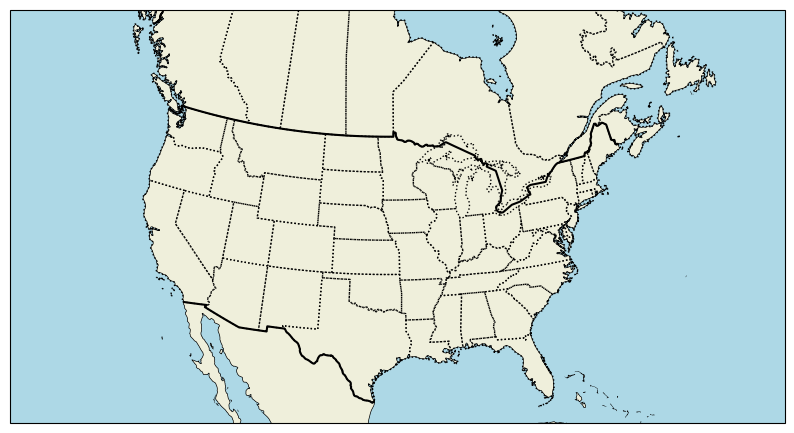

In [37]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal())

ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.5)
ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':', linewidth=1)

ax.set_extent([-130, -60, 20, 55])